<a href="https://colab.research.google.com/github/Zubair2720/TSA/blob/main/Twitter_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
 import os

print(os.listdir('/content/drive/MyDrive'))

['Untitled folder', 'GK class 3.docx', 'tayyab dg (1).docx', 'tayyab dg.docx', 'cover letter.docx', 'cover.docx', 'Untitled spreadsheet.gsheet', 'CUSTOMER SERVICE PROFILE.pdf', '17744179908494479871551668187829.jpg', 'Colab Notebooks', 'CV....pdf', 'archive (18).zip', 'archive (19).zip', 'twitter_dataset']


In [ ]:
zip_path = '/content/drive/MyDrive/archive (19).zip'

print(os.path.exists(zip_path))

True


In [ ]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/archive (19).zip'
extract_path = '/content/drive/MyDrive/twitter_dataset'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(os.listdir(extract_path))

['twitter_validation.csv', 'twitter_training.csv']


In [ ]:
import numpy as np
import re
import pickle
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Bidirectional

In [ ]:
from google.colab import drive
drive.mount('/content/drive')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
columns = ['tweet_id', 'entity', 'sentiment', 'text']

df = pd.read_csv(
    '/content/drive/MyDrive/twitter_dataset/twitter_training.csv',
    header=None,
    names=columns
)

In [ ]:
# 2. Clean
def clean_tweet(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'@\w+', ' ', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df = df.dropna(subset=['text']).reset_index(drop=True)
df['clean_text'] = df['text'].apply(clean_tweet)
df = df[df['clean_text'].str.len() > 0].reset_index(drop=True)

In [ ]:
# Label Encodes
encoder = LabelEncoder()
df['label'] = encoder.fit_transform(df['sentiment'])

X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'], df['label'], test_size=0.2, random_state=42, stratify=df['label']
)

In [ ]:
# TF-ID
svm_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=20000, ngram_range=(1, 2))),
    ('clf', LinearSVC(max_iter=2000))
])

svm_pipeline.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=20000, ngram_range=(1, 2))),
                ('clf', LinearSVC(max_iter=2000))])

In [ ]:
# Evaluate
y_pred = svm_pipeline.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")
print(classification_report(y_test, y_pred, target_names=encoder.classes_))

Accuracy: 0.8436
              precision    recall  f1-score   support

  Irrelevant       0.85      0.77      0.81      2562
    Negative       0.86      0.88      0.87      4451
     Neutral       0.84      0.83      0.84      3596
    Positive       0.82      0.86      0.84      4116

    accuracy                           0.84     14725
   macro avg       0.84      0.84      0.84     14725
weighted avg       0.84      0.84      0.84     14725



In [ ]:
# For streamlit
with open('sentiment_svm_pipeline.pkl', 'wb') as f:
    pickle.dump(svm_pipeline, f)

with open('encoder.pkl', 'wb') as f:
    pickle.dump(encoder, f)

print("Saved: sentiment_svm_pipeline.pkl,encoder.pkl")

Saved: sentiment_svm_pipeline.pkl,encoder.pkl


In [ ]:
# SimpleRNN
NUM_CLASSES = len(encoder.classes_)

# 1. Data-driven MAX_LEN — same 95th-percentile approach
word_count = X_train.str.split().apply(len)
vocab_size = 20000
max_len = int(word_count.quantile(0.95))
print(f"MAX_LEN (95th percentile): {max_len}")

MAX_LEN (95th percentile): 48


In [ ]:
# 2. TextVectorization adapted on training text only
vectorize_layer = tf.keras.layers.TextVectorization(
    max_tokens=vocab_size,
    output_mode='int',
    output_sequence_length=max_len
)
vectorize_layer.adapt(X_train.values)

In [ ]:
# 3. tf.data pipelines
BATCH_SIZE = 64

train_ds = tf.data.Dataset.from_tensor_slices(
    (X_train.values, y_train.values)
).shuffle(10000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices(
    (X_test.values, y_test.values)
).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout
from tensorflow.keras.utils import to_categorical

In [ ]:
# 4. Model — TextVectorization lives INSIDE the model
EMBEDDING_DIM = 128
RNN_UNITS = 64

rnn_model = tf.keras.Sequential([
    tf.keras.Input(shape=(), dtype=tf.string),
    vectorize_layer,
    tf.keras.layers.Embedding(vocab_size, EMBEDDING_DIM, mask_zero=True),
    Bidirectional(SimpleRNN(128, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(SimpleRNN(64)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(4, activation='softmax')
])


In [ ]:
rnn_model.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])
rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ (None, 48)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 48, 128)        │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 48, 256)        │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 48, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,675,396 (10.21 MB)

 Trainable params: 2,675,396 (10.21 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#  Train
early_stopping = EarlyStopping(monitor='val_accuracy', mode='max', patience=5, restore_best_weights=True)

history = rnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=[early_stopping],
    verbose=2
)


Epoch 1/5
921/921 - 163s - 177ms/step - accuracy: 0.6009 - loss: 0.9644 - val_accuracy: 0.7812 - val_loss: 0.6032
Epoch 2/5
921/921 - 150s - 163ms/step - accuracy: 0.8503 - loss: 0.4166 - val_accuracy: 0.8503 - val_loss: 0.4276
Epoch 3/5
921/921 - 149s - 162ms/step - accuracy: 0.9118 - loss: 0.2444 - val_accuracy: 0.8676 - val_loss: 0.4098
Epoch 4/5
921/921 - 151s - 164ms/step - accuracy: 0.9317 - loss: 0.1858 - val_accuracy: 0.8757 - val_loss: 0.3831
Epoch 5/5
921/921 - 151s - 164ms/step - accuracy: 0.9422 - loss: 0.1548 - val_accuracy: 0.8801 - val_loss: 0.3872


In [ ]:
# Best epoch result
best_epoch = int(np.argmax(history.history['val_accuracy']))
print(f"Best epoch: {best_epoch + 1}")
print(f"SimpleRNN validation accuracy: {history.history['val_accuracy'][best_epoch]:.4f}")

Best epoch: 5
SimpleRNN validation accuracy: 0.8801


In [ ]:
results = {}
# 7. Add to results dict (if you're tracking ML model scores in `results`)
results['SimpleRNN'] = history.history['val_accuracy'][best_epoch]

In [ ]:
# 8. Save — .keras, not .pkl
rnn_model.save('sentiment_rnn_model.keras')
print("Saved: sentiment_rnn_model.keras")

Saved: sentiment_rnn_model.keras


In [ ]:
from google.colab import files
files.download('sentiment_rnn_model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
rnn_model.save("sentiment_rnn_model1.keras", include_optimizer=False)

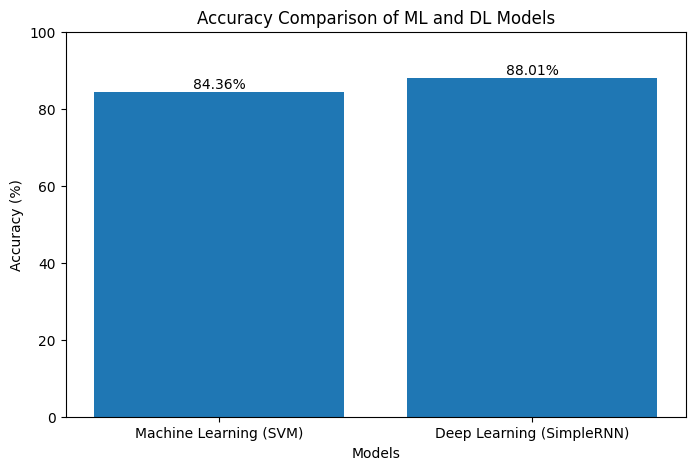

In [ ]:
import matplotlib.pyplot as plt

# ML accuracy
ml_accuracy = acc

# DL accuracy
dl_accuracy = history.history['val_accuracy'][best_epoch]

# Model names and accuracies
models = ['Machine Learning (SVM)', 'Deep Learning (SimpleRNN)']
accuracies = [ml_accuracy, dl_accuracy]

# Convert to percentage
accuracies_percentage = [x * 100 for x in accuracies]

# Plot
plt.figure(figsize=(8, 5))

bars = plt.bar(models, accuracies_percentage)

plt.title('Accuracy Comparison of ML and DL Models')
plt.xlabel('Models')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)

# Show accuracy on bars
for bar, accuracy in zip(bars, accuracies_percentage):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1,
        f'{accuracy:.2f}%',
        ha='center'
    )

plt.show()